CSV saved as 'movie_sample_dataset.csv'. Here's the dataset:

Movies clustered into groups:
               Title  Cluster
0         The Matrix        1
1            Titanic        2
2          Inception        1
3      The Lion King        0
4       Forrest Gump        1
5      The Godfather        1
6  Avengers: Endgame        1
7              Joker        1
8          Toy Story        1
9       Pulp Fiction        1


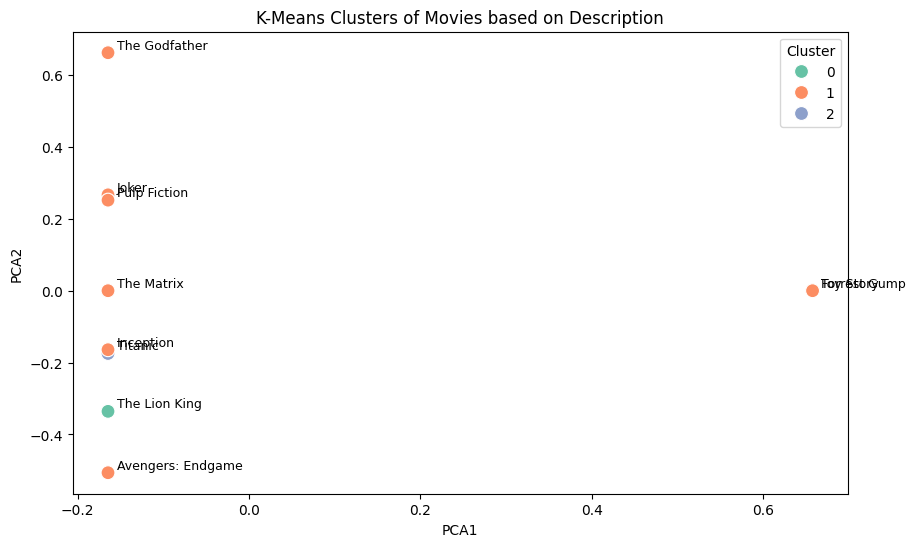

In [1]:
# Jupyter Notebook: Movie Dataset K-Means + NLP Example

# Step 1: Import libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Create a sample movie dataset
data = {
    'Title': [
        'The Matrix', 'Titanic', 'Inception', 'The Lion King', 
        'Forrest Gump', 'The Godfather', 'Avengers: Endgame', 
        'Joker', 'Toy Story', 'Pulp Fiction'
    ],
    'Genre': [
        'Action Sci-Fi', 'Romance Drama', 'Action Sci-Fi Thriller', 
        'Animation Adventure', 'Drama Romance', 'Crime Drama', 
        'Action Adventure', 'Crime Drama Thriller', 'Animation Comedy', 
        'Crime Drama'
    ],
    'Description': [
        'A hacker discovers the reality is a simulation.',
        'A young couple falls in love aboard the doomed ship Titanic.',
        'A thief steals corporate secrets through dream-sharing technology.',
        'A lion cub learns to become king of the Pride Lands.',
        'Life story of Forrest Gump, a man with a low IQ but good intentions.',
        'The aging patriarch of an organized crime dynasty transfers control to his son.',
        'The Avengers assemble to reverse the damage caused by Thanos.',
        'A mentally troubled comedian descends into madness and becomes the Joker.',
        'Toys come to life when humans are not around, leading to adventures.',
        'The lives of two mob hitmen, a boxer, and others intertwine in Los Angeles.'
    ]
}

# Step 3: Convert to DataFrame and save CSV
df = pd.DataFrame(data)
df.to_csv('movie_sample_dataset.csv', index=False)
print("CSV saved as 'movie_sample_dataset.csv'. Here's the dataset:")
df.head()

# Step 4: NLP - TF-IDF vectorization of movie descriptions
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Description'])

# Step 5: K-Means clustering
num_clusters = 3  # You can change this based on your preference
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(tfidf_matrix)

# Step 6: Show clustering results
print("\nMovies clustered into groups:")
print(df[['Title', 'Cluster']])

# Step 7: Visualize clusters (optional, using first two PCA components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())
df['PCA1'] = reduced_features[:,0]
df['PCA2'] = reduced_features[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
for i, row in df.iterrows():
    plt.text(row['PCA1']+0.01, row['PCA2']+0.01, row['Title'], fontsize=9)
plt.title("K-Means Clusters of Movies based on Description")
plt.show()